<a href="https://colab.research.google.com/github/jananiksaagash-rgb/AppliedAI/blob/main/Ex11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 215s 665ms/step - accuracy: 0.4586 - loss: 1.5872 - val_accuracy: 0.7200 - val_loss: 0.9332
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 186s 596ms/step - accuracy: 0.6960 - loss: 0.9281 - val_accuracy: 0.7600 - val_loss: 0.7361
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 209s 617ms/step - accuracy: 0.7546 - loss: 0.7360 - val_accuracy: 0.7890 - val_loss: 0.6577
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 203s 620ms/step - accuracy: 0.7922 - loss: 0.6278 - val_accuracy: 0.7990 - val_loss: 0.6087
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 201s 619ms/step - accuracy: 0.8082 - loss: 0.5785 - val_accuracy: 0.8080 - val_loss: 0.5893


Saving Screenshot 2026-04-12 213733.png to Screenshot 2026-04-12 213733.png


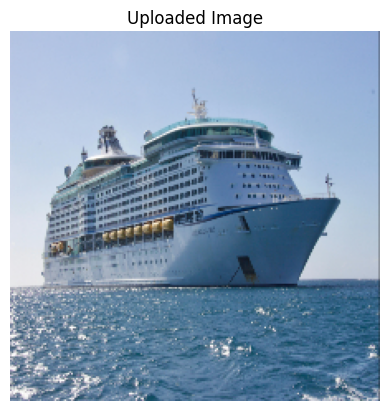

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
🐾 Predicted Class: ship


In [1]:
# ==============================
# ANIMAL IMAGE CLASSIFICATION
# TRANSFER LEARNING - MOBILE NET V2
# ==============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# ------------------------------
# 1. Load dataset (CIFAR-10 - animal subset)
# ------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Take small subset (fast training)
x_train = x_train[:5000]
y_train = y_train[:5000]
x_test = x_test[:1000]
y_test = y_test[:1000]

# ------------------------------
# 2. Resize images to 224x224
# ------------------------------
import cv2

x_train = np.array([cv2.resize(img, (224,224)) for img in x_train])
x_test = np.array([cv2.resize(img, (224,224)) for img in x_test])

# ------------------------------
# 3. Preprocess
# ------------------------------
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

# ------------------------------
# 4. Animal Classes (ONLY animals from CIFAR-10)
# ------------------------------
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ------------------------------
# 5. Build Transfer Learning Model
# ------------------------------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ------------------------------
# 6. Compile Model
# ------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------
# 7. Train Model
# ------------------------------
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=16,
    validation_data=(x_test, y_test)
)

# ------------------------------
# 8. Upload Image for Prediction
# ------------------------------
from google.colab import files
uploaded = files.upload()

# ------------------------------
# 9. Predict Image
# ------------------------------
for fn in uploaded.keys():

    img = cv2.imread(fn)
    img = cv2.resize(img, (224,224))

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    print("🐾 Predicted Class:", class_names[class_index])